In [ ]:
!pip install pymatgen mp-api umap-learn imbalanced-learn scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 141.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 16.8 MB/s eta 0:00:00

Import Library

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

In [ ]:
# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

API_KEY = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN = 10
TWO_THETA_MAX = 110
N_POINTS = 2048
MAX_PER_CLASS = 50000

SEED = 42
EPOCHS_FINAL = 10
BATCH_SIZE = 32

# Set seed for reproducibility
def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")
print(f"Target crystal systems: {TARGET_SYSTEMS}")
print(f"Data Split Ratio - Training:Validation:Testing = 70:10:20")

Seed set to 42
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']
Data Split Ratio - Training:Validation:Testing = 70:10:20


CONFIGURATION & SETUP

In [ ]:
def load_perovskite_data_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """Load perovskite data from Materials Project"""

    data_records = []
    class_counts = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        # Search for perovskite materials
        robo_docs = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids = [str(doc.material_id) for doc in robo_docs][:50000]

        print(f"Found {len(perov_mpids)} perovskite materials")

        # Get material summaries
        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry", "formula_pretty",
                   "density", "volume", "nsites"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system
            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()

            if cs not in TARGET_SYSTEMS:
                continue
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            # Collect data
            record = {
                'material_id': str(doc.material_id),
                'formula': str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                'crystal_system': cs,
                'density': float(doc.density) if hasattr(doc, 'density') else None,
                'volume': float(doc.volume) if hasattr(doc, 'volume') else None,
                'nsites': int(doc.nsites) if hasattr(doc, 'nsites') else None,
                'structure': structure
            }

            data_records.append(record)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    print(f"\nTotal materials collected: {len(data_records)}")
    print(f"Class distribution: {class_counts}")

    return pd.DataFrame(data_records)

# Load data
print("Loading data from Materials Project...")
df_materials = load_perovskite_data_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")

Loading data from Materials Project...


Retrieving RobocrystallogapherDoc documents:   0%|          | 0/8509 [00:00<?, ?it/s]

Found 8509 perovskite materials


Retrieving SummaryDoc documents:   0%|          | 0/7886 [00:00<?, ?it/s]


Total materials collected: 7015
Class distribution: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}

Dataset shape: (7015, 7)


Exploratory Data Analysis - Data Types & Sample Data

In [ ]:
# ============================================================================
# DATA EXPLORATION
# ============================================================================

# Check data types
print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(df_materials.dtypes)
print()

# Display columns/features
print("="*70)
print("COLUMNS/FEATURES")
print("="*70)
print(f"Columns: {list(df_materials.columns)}")
print()

# Display top 4 samples (excluding structure column for readability)
print("="*70)
print("TOP 4 SAMPLES (Preview)")
print("="*70)
display_df = df_materials.drop(columns=['structure']).head(4)
print(display_df.to_string())


DATA TYPES
material_id        object
formula            object
crystal_system     object
density           float64
volume            float64
nsites              int64
structure          object
dtype: object

COLUMNS/FEATURES
Columns: ['material_id', 'formula', 'crystal_system', 'density', 'volume', 'nsites', 'structure']

TOP 4 SAMPLES (Preview)
  material_id formula crystal_system   density     volume  nsites
0  mp-1183288  BaInO3          cubic  6.331162  78.721649       5
1  mp-1183286  BaDyO3          cubic  6.651911  86.828787       5
2  mp-1183284  BaLiO3          cubic  4.677365  68.257565       5
3  mp-1183282  BaBeO3          cubic  5.464992  59.049462       5


Check Missing Values

In [ ]:
# ============================================================================
# MISSING VALUES ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_data = df_materials.isnull().sum()
missing_percent = (df_materials.isnull().sum() / len(df_materials)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
})

print(missing_df.to_string(index=False))

# Visualize missing values only if there are any
if missing_percent.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_percent[missing_percent > 0].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontweight='bold', fontsize=14)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n⚠ Total missing values: {missing_data.sum()}")
else:
    print("\n" + "="*70)
    print("✓ NO MISSING VALUES FOUND!")
    print("="*70)
    print("All columns are complete. Data quality is excellent!")


MISSING VALUES ANALYSIS
        Column  Missing Count  Missing Percentage
   material_id              0                 0.0
       formula              0                 0.0
crystal_system              0                 0.0
       density              0                 0.0
        volume              0                 0.0
        nsites              0                 0.0
     structure              0                 0.0

✓ NO MISSING VALUES FOUND!
All columns are complete. Data quality is excellent!


Crystal System Distribution (Before XRD)


CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)

Count by Crystal System:
crystal_system
cubic           4877
orthorhombic    1003
monoclinic       869
tetragonal       266
Name: count, dtype: int64

Percentage by Crystal System:
  Cubic          :  69.52%
  Orthorhombic   :  14.30%
  Monoclinic     :  12.39%
  Tetragonal     :   3.79%


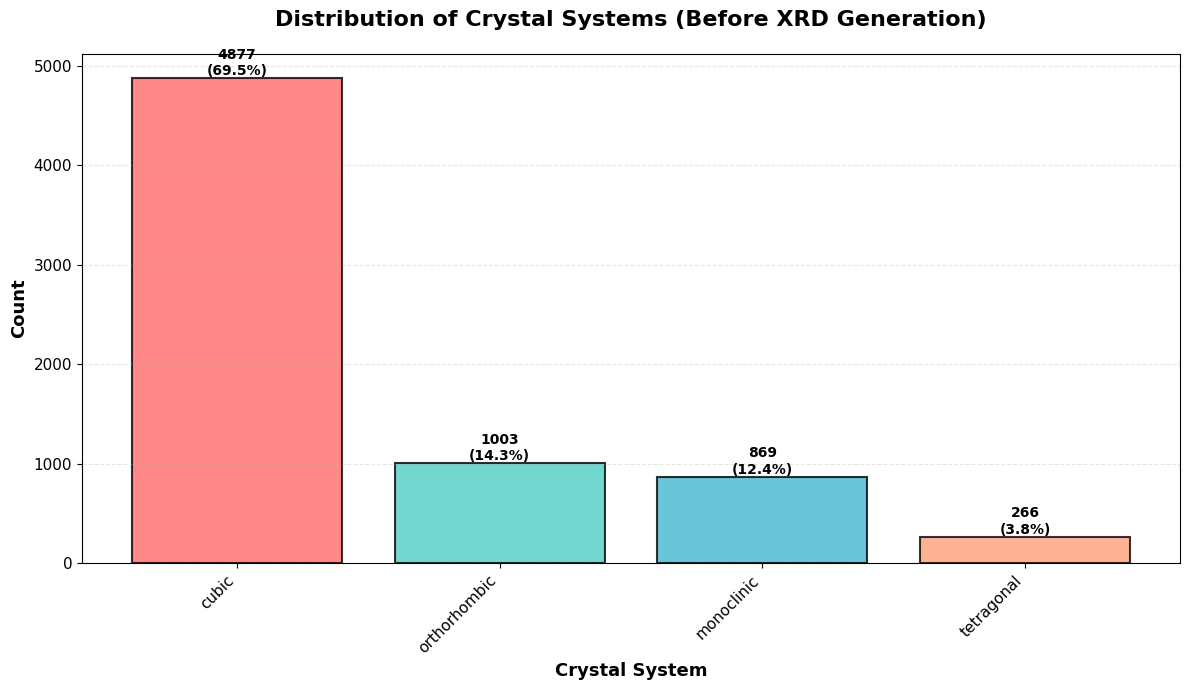

In [ ]:
# ============================================================================
# CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)
# ============================================================================

print("\n" + "="*70)
print("CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)")
print("="*70)

class_distribution = df_materials['crystal_system'].value_counts()
print("\nCount by Crystal System:")
print(class_distribution)

print("\nPercentage by Crystal System:")
class_distribution_pct = (class_distribution / len(df_materials) * 100).round(2)
for system, pct in class_distribution_pct.items():
    print(f"  {system.capitalize():<15}: {pct:>6.2f}%")

# Plot distribution
plt.figure(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(class_distribution.index, class_distribution.values,
               color=colors[:len(class_distribution)],
               edgecolor='black', linewidth=1.5, alpha=0.8)

plt.title('Distribution of Crystal Systems (Before XRD Generation)',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Crystal System', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df_materials)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Generate XRD Patterns

In [ ]:
def generate_xrd_patterns(df_materials, two_theta_min=TWO_THETA_MIN,
                         two_theta_max=TWO_THETA_MAX, n_points=N_POINTS):
    """Generate XRD patterns from structures"""

    two_theta_grid = np.linspace(two_theta_min, two_theta_max, n_points)
    X_patterns = []
    y_systems = []
    valid_indices = []
    failed_count = 0

    xrd_calc = XRDCalculator(wavelength="CuKa")

    print("="*70)
    print("GENERATING XRD PATTERNS")
    print("="*70)
    print(f"2θ range: {two_theta_min}° - {two_theta_max}°")
    print(f"Number of points: {n_points}")
    print(f"Wavelength: Cu Kα")
    print()

    total = len(df_materials)

    for idx, row in df_materials.iterrows():
        try:
            structure = row['structure']
            pattern = xrd_calc.get_pattern(
                structure,
                two_theta_range=(two_theta_min, two_theta_max),
            )
            intensities = np.interp(two_theta_grid, pattern.x, pattern.y)

            X_patterns.append(intensities)
            y_systems.append(row['crystal_system'])
            valid_indices.append(idx)

        except Exception as e:
            failed_count += 1
            if failed_count <= 3:  # Only show first 3 errors
                print(f"✗ Error for {row['material_id']}: {str(e)[:50]}...")
            continue

        if (len(X_patterns) % 500) == 0:
            print(f"✓ Processed {len(X_patterns)}/{total} patterns... ({len(X_patterns)/total*100:.1f}%)")

    X_patterns = np.array(X_patterns, dtype=np.float32)
    y_systems = np.array(y_systems)

    print()
    print("="*70)
    print("XRD GENERATION SUMMARY")
    print("="*70)
    print(f"✓ Successfully generated: {len(X_patterns)} patterns")
    print(f"✗ Failed: {failed_count} patterns")
    print(f"Success rate: {len(X_patterns)/(len(X_patterns)+failed_count)*100:.2f}%")
    print(f"Pattern shape: {X_patterns.shape}")
    print(f"Crystal system distribution:\n{Counter(y_systems)}")

    return two_theta_grid, X_patterns, y_systems, valid_indices

# Generate XRD patterns
two_theta_grid, X_raw, y_str, valid_idx = generate_xrd_patterns(df_materials)

# Update dataframe to keep only valid materials
df_materials = df_materials.iloc[valid_idx].reset_index(drop=True)

print(f"\n✓ Final dataset size: {len(X_raw)} samples")

GENERATING XRD PATTERNS
2θ range: 10° - 110°
Number of points: 2048
Wavelength: Cu Kα

✓ Processed 500/7015 patterns... (7.1%)
✓ Processed 1000/7015 patterns... (14.3%)
✓ Processed 1500/7015 patterns... (21.4%)
✓ Processed 2000/7015 patterns... (28.5%)
✓ Processed 2500/7015 patterns... (35.6%)
✓ Processed 3000/7015 patterns... (42.8%)
✓ Processed 3500/7015 patterns... (49.9%)
✓ Processed 4000/7015 patterns... (57.0%)
✓ Processed 4500/7015 patterns... (64.1%)
✓ Processed 5000/7015 patterns... (71.3%)
✓ Processed 5500/7015 patterns... (78.4%)
✓ Processed 6000/7015 patterns... (85.5%)
✓ Processed 6500/7015 patterns... (92.7%)
✓ Processed 7000/7015 patterns... (99.8%)

XRD GENERATION SUMMARY
✓ Successfully generated: 7015 patterns
✗ Failed: 0 patterns
Success rate: 100.00%
Pattern shape: (7015, 2048)
Crystal system distribution:
Counter({np.str_('cubic'): 4877, np.str_('orthorhombic'): 1003, np.str_('monoclinic'): 869, np.str_('tetragonal'): 266})

✓ Final dataset size: 7015 samples


Visualize XRD Patterns for Each Crystal System


XRD PATTERN VISUALIZATION
Displaying 1 sample per crystal system (sorted by 2θ)
Plotting Cubic: 4877 samples available
Plotting Monoclinic: 869 samples available
Plotting Orthorhombic: 1003 samples available
Plotting Tetragonal: 266 samples available


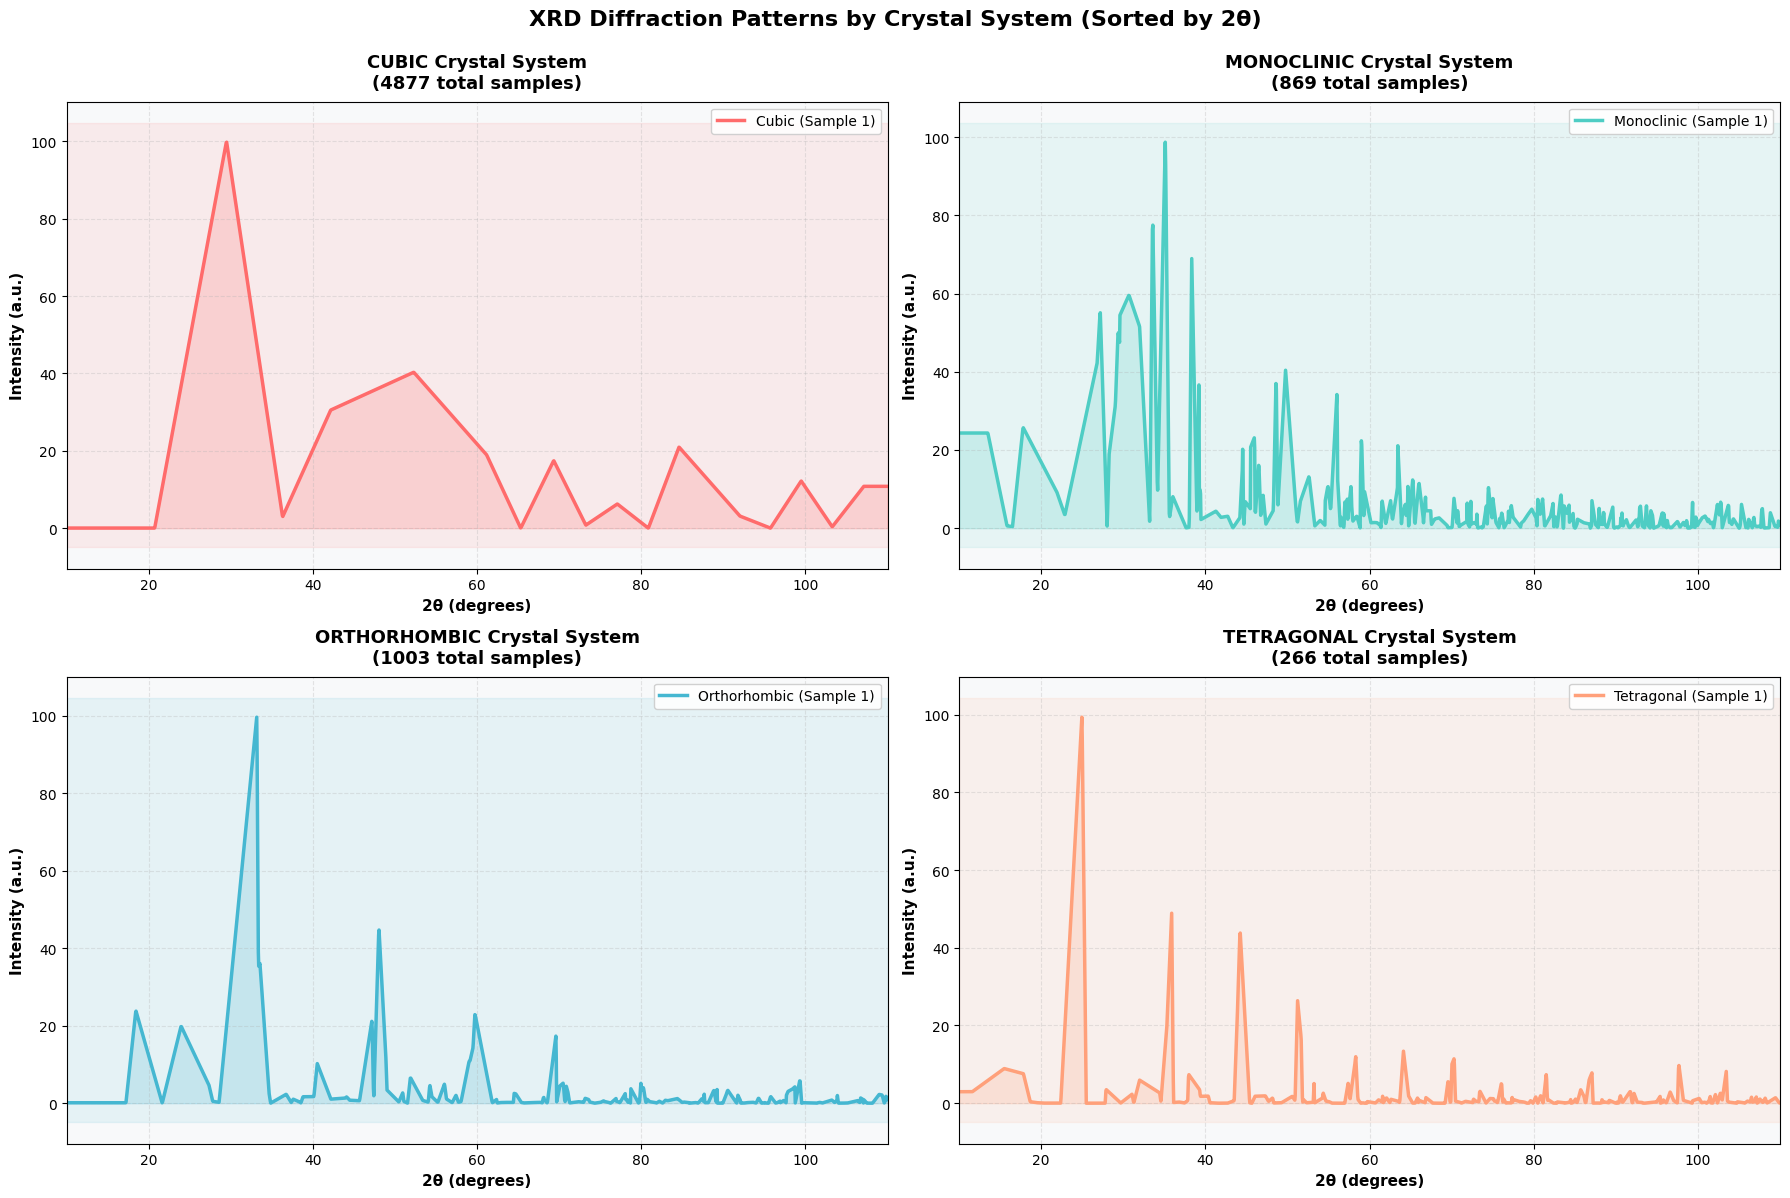


✓ XRD patterns visualization complete!
✓ Each pattern is sorted by 2θ angle


In [ ]:
# ============================================================================
# XRD PATTERN VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("XRD PATTERN VISUALIZATION")
print("="*70)
print("Displaying 1 sample per crystal system (sorted by 2θ)")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

colors_map = {
    'cubic': '#FF6B6B',
    'monoclinic': '#4ECDC4',
    'orthorhombic': '#45B7D1',
    'tetragonal': '#FFA07A'
}

for idx, system in enumerate(TARGET_SYSTEMS):
    ax = axes[idx]

    # Get indices for this system
    system_indices = np.where(y_str == system)[0]

    print(f"Plotting {system.capitalize()}: {len(system_indices)} samples available")

    if len(system_indices) > 0:
        # Take only 1 sample (first sample)
        sample_idx = system_indices[0]

        # Get pattern data
        pattern_data = X_raw[sample_idx]

        # Sort by 2θ (should already be sorted, but ensuring)
        sorted_indices = np.argsort(two_theta_grid)
        two_theta_sorted = two_theta_grid[sorted_indices]
        pattern_sorted = pattern_data[sorted_indices]

        # Plot the sorted pattern
        ax.plot(two_theta_sorted, pattern_sorted,
               linewidth=2.5,
               color=colors_map[system],
               label=f'{system.capitalize()} (Sample 1)')

        # Fill under the curve for better visualization
        ax.fill_between(two_theta_sorted, pattern_sorted,
                        alpha=0.2, color=colors_map[system])

    ax.set_title(f'{system.upper()} Crystal System\n({len(system_indices)} total samples)',
                fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('2θ (degrees)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')

    # Add subtle background color
    ax.axhspan(ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color=colors_map[system])

    # Set x-axis limits
    ax.set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)

plt.suptitle('XRD Diffraction Patterns by Crystal System (Sorted by 2θ)',
            fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ XRD patterns visualization complete!")
print("✓ Each pattern is sorted by 2θ angle")

Encode Labels & Split Data

In [ ]:
# ============================================================================
# DATA PREPARATION: ENCODING & SPLITTING (70:10:20)
# ============================================================================

print("\n" + "="*70)
print("DATA PREPARATION: ENCODING & SPLITTING")
print("="*70)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_str)
class_names = list(le.classes_)

print("\nClass Encoding Mapping:")
for i, name in enumerate(class_names):
    count = np.sum(y_encoded == i)
    print(f"  {i} → {name.capitalize():<15} ({count} samples)")

# Split data: 70% train, 10% validation, 20% test
# First split: 80% (train+val), 20% test
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

# Second split: 70% train, 10% validation (from the 80%)
# 10/80 = 0.125
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=SEED,
    stratify=y_temp
)

print("\n" + "-"*70)
print("DATA SPLIT (70% Train / 10% Validation / 20% Test)")
print("-"*70)
print(f"Training set size:     {len(X_train_raw):>6} samples ({len(X_train_raw)/len(X_raw)*100:.1f}%)")
print(f"Validation set size:   {len(X_val_raw):>6} samples ({len(X_val_raw)/len(X_raw)*100:.1f}%)")
print(f"Test set size:         {len(X_test_raw):>6} samples ({len(X_test_raw)/len(X_raw)*100:.1f}%)")
print(f"Total:                 {len(X_raw):>6} samples")

print("\nTraining Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_train)*100:>5.1f}%)")

print("\nValidation Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_val)*100:>5.1f}%)")

print("\nTest Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_test)*100:>5.1f}%)")


DATA PREPARATION: ENCODING & SPLITTING

Class Encoding Mapping:
  0 → Cubic           (4877 samples)
  1 → Monoclinic      (869 samples)
  2 → Orthorhombic    (1003 samples)
  3 → Tetragonal      (266 samples)

----------------------------------------------------------------------
DATA SPLIT (70% Train / 10% Validation / 20% Test)
----------------------------------------------------------------------
Training set size:       4910 samples (70.0%)
Validation set size:      702 samples (10.0%)
Test set size:           1403 samples (20.0%)
Total:                   7015 samples

Training Set Distribution:
  Cubic          :  3414 samples ( 69.5%)
  Monoclinic     :   608 samples ( 12.4%)
  Orthorhombic   :   702 samples ( 14.3%)
  Tetragonal     :   186 samples (  3.8%)

Validation Set Distribution:
  Cubic          :   488 samples ( 69.5%)
  Monoclinic     :    87 samples ( 12.4%)
  Orthorhombic   :   100 samples ( 14.2%)
  Tetragonal     :    27 samples (  3.8%)

Test Set Distribution:
 

Apply SMOTE (Training Data Only)

In [ ]:
print("\n" + "="*70)
print("APPLYING SMOTE OVERSAMPLING (TRAINING DATA ONLY)")
print("="*70)

print("\nBEFORE SMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

# Apply SMOTE
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train)

print("\n" + "="*70)
print("AFTER SMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_smote)} (increased by {len(X_train_smote) - len(X_train_raw)})")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train_smote == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n" + "="*70)
print("TEST SET (UNCHANGED - NO OVERSAMPLING):")
print("-" * 50)
print(f"Test samples: {len(X_test_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n✓ SMOTE oversampling applied successfully!")
print(f"✓ Training data balanced: all classes now have {np.max(np.bincount(y_train_smote))} samples")


APPLYING SMOTE OVERSAMPLING (TRAINING DATA ONLY)

BEFORE SMOTE:
--------------------------------------------------
Training samples: 4910

Class distribution:
  Cubic          :  3414 samples
  Monoclinic     :   608 samples
  Orthorhombic   :   702 samples
  Tetragonal     :   186 samples

AFTER SMOTE:
--------------------------------------------------
Training samples: 13656 (increased by 8746)

Class distribution:
  Cubic          :  3414 samples
  Monoclinic     :  3414 samples
  Orthorhombic   :  3414 samples
  Tetragonal     :  3414 samples

TEST SET (UNCHANGED - NO OVERSAMPLING):
--------------------------------------------------
Test samples: 1403

Class distribution:
  Cubic          :   975 samples
  Monoclinic     :   174 samples
  Orthorhombic   :   201 samples
  Tetragonal     :    53 samples

✓ SMOTE oversampling applied successfully!
✓ Training data balanced: all classes now have 3414 samples


Visualize Distribution After SMOTE

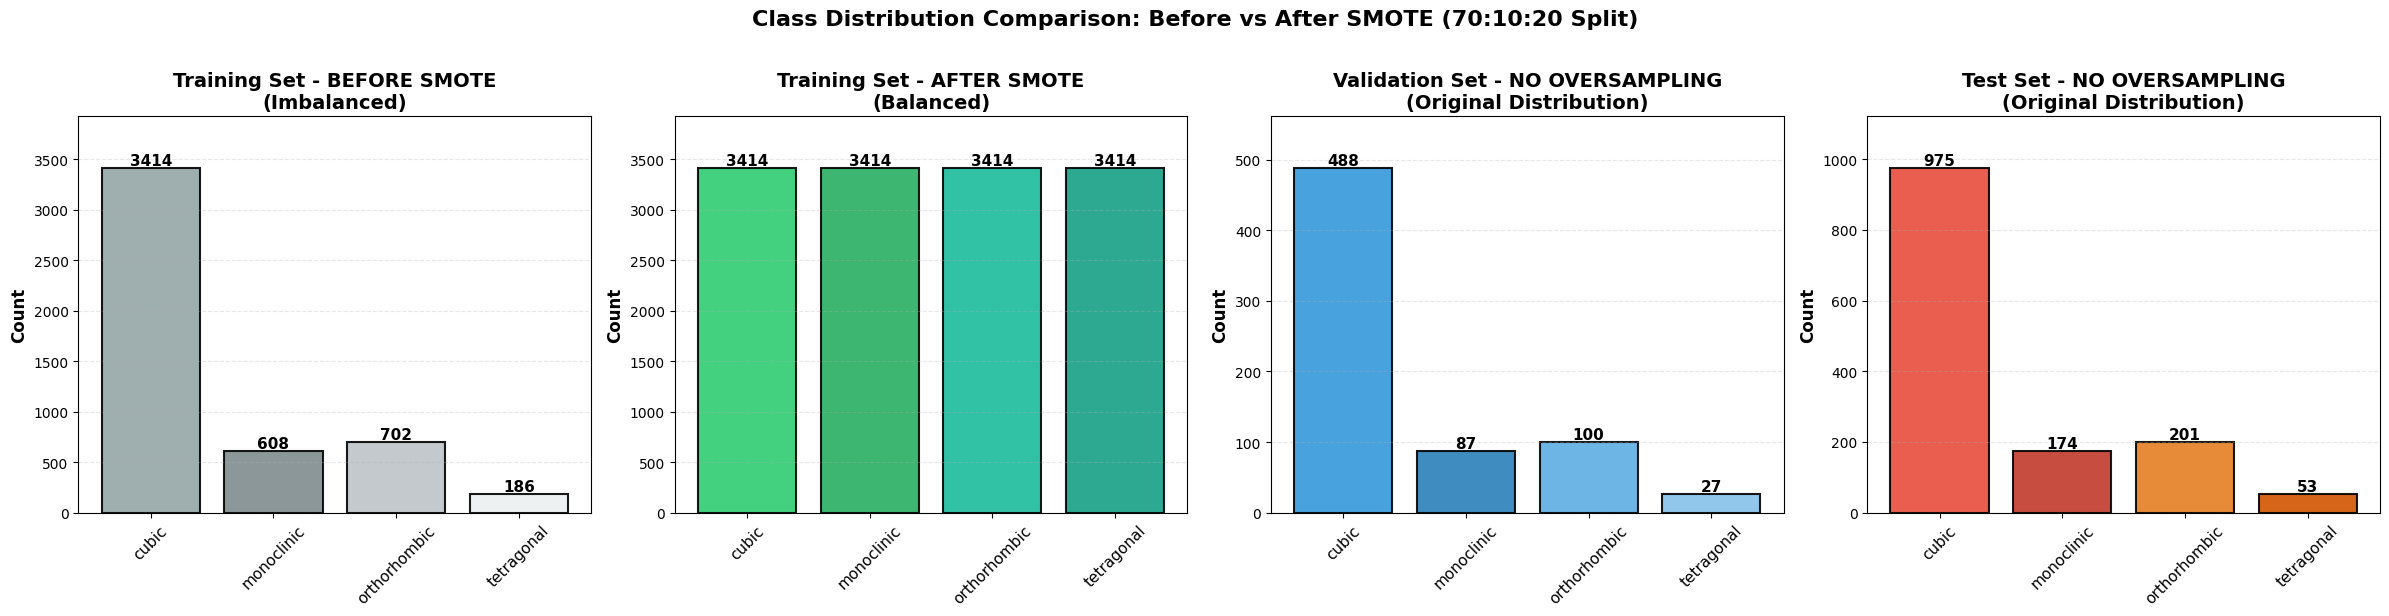

In [ ]:
# ============================================================================
# VISUALIZE CLASS DISTRIBUTION COMPARISON
# ============================================================================

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Color palettes
colors_before = ['#95a5a6', '#7f8c8d', '#bdc3c7', '#ecf0f1']
colors_after = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
colors_val = ['#3498db', '#2980b9', '#5dade2', '#85c1e9']
colors_test = ['#e74c3c', '#c0392b', '#e67e22', '#d35400']

# Plot 1: Training Before SMOTE
unique, counts = np.unique(y_train, return_counts=True)
labels = [class_names[i] for i in unique]
bars1 = axes[0].bar(labels, counts, color=colors_before, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[0].set_title('Training Set - BEFORE SMOTE\n(Imbalanced)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars1, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Training After SMOTE
unique, counts = np.unique(y_train_smote, return_counts=True)
labels = [class_names[i] for i in unique]
bars2 = axes[1].bar(labels, counts, color=colors_after, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[1].set_title('Training Set - AFTER SMOTE\n(Balanced)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars2, counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: Validation Set
unique, counts = np.unique(y_val, return_counts=True)
labels = [class_names[i] for i in unique]
bars3 = axes[2].bar(labels, counts, color=colors_val, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[2].set_title('Validation Set - NO OVERSAMPLING\n(Original Distribution)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=11)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars3, counts):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 4: Test Set
unique, counts = np.unique(y_test, return_counts=True)
labels = [class_names[i] for i in unique]
bars4 = axes[3].bar(labels, counts, color=colors_test, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[3].set_title('Test Set - NO OVERSAMPLING\n(Original Distribution)', fontweight='bold', fontsize=14)
axes[3].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[3].tick_params(axis='x', rotation=45, labelsize=11)
axes[3].grid(axis='y', alpha=0.3, linestyle='--')
axes[3].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars4, counts):
    height = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Class Distribution Comparison: Before vs After SMOTE (70:10:20 Split)',
            fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Display Sample Counts Summary

In [ ]:
# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("SAMPLE COUNTS SUMMARY TABLE")
print("="*70)

summary_data = []
total_train_before = 0
total_train_after = 0
total_val = 0
total_test = 0

for i, system in enumerate(class_names):
    train_before = np.sum(y_train == i)
    train_after = np.sum(y_train_smote == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)

    total_train_before += train_before
    total_train_after += train_after
    total_val += val_count
    total_test += test_count

    increase = train_after - train_before
    increase_pct = (increase / train_before * 100) if train_before > 0 else 0

    summary_data.append({
        'Crystal System': system.capitalize(),
        'Train (Before)': train_before,
        'Train (After)': train_after,
        'Increase': f'+{increase}',
        'Increase %': f'+{increase_pct:.1f}%',
        'Validation': val_count,
        'Test': test_count
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "-"*70)
print(f"{'TOTAL':<20} {total_train_before:>13} {total_train_after:>14} {f'+{total_train_after-total_train_before}':>10} {f'+{(total_train_after-total_train_before)/total_train_before*100:.1f}%':>12} {total_val:>12} {total_test:>6}")
print("="*70)

print(f"\n✓ SMOTE oversampling increased training samples by {(total_train_after - total_train_before) / total_train_before * 100:.1f}%")


SAMPLE COUNTS SUMMARY TABLE
Crystal System  Train (Before)  Train (After) Increase Increase %  Validation  Test
         Cubic            3414           3414       +0      +0.0%         488   975
    Monoclinic             608           3414    +2806    +461.5%          87   174
  Orthorhombic             702           3414    +2712    +386.3%         100   201
    Tetragonal             186           3414    +3228   +1735.5%          27    53

----------------------------------------------------------------------
TOTAL                         4910          13656      +8746      +178.1%          702   1403

✓ SMOTE oversampling increased training samples by 178.1%


Build & Train CNN Model

In [ ]:
# ============================================================================
# MODEL ARCHITECTURE DEFINITIONS
# ============================================================================

def build_cnn_fixed(input_shape, num_classes: int):
    """
    Build CNN with fixed architecture
    - 3 Conv1D layers: filters=80, kernel_size=[100, 80, 20], stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout
    """
    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: 80 filters, kernel_size=100, stride=5
    x = layers.Conv1D(filters=80, kernel_size=100, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: 80 filters, kernel_size=80, stride=5
    x = layers.Conv1D(filters=80, kernel_size=80, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: 80 filters, kernel_size=20, stride=5
    x = layers.Conv1D(filters=80, kernel_size=20, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(64, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_Fixed")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def build_cnn_woa(params, input_shape, num_classes):
    """
    Build CNN with WOA-optimized hyperparameters
    Architecture:
    - 3 Conv1D layers: all with kernel_size optimized, stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout

    WOA optimizes:
    - Number of filters for all 3 conv layers (same value)
    - Fully connected layer 1 units
    - Fully connected layer 2 units (feature layer)
    """
    num_filters = int(params[0])      # Filters for all 3 conv layers
    fc1_units = int(params[1])        # FC layer 1 units
    fc2_units = int(params[2])        # FC layer 2 units (feature layer)

    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: kernel_size=100, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=100, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: kernel_size=80, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=80, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: kernel_size=20, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=20, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(fc1_units, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(fc2_units, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_WOA")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

PREPARE DATA FOR TRAINING

In [ ]:
# ============================================================================
# PREPARE DATA FOR TRAINING
# ============================================================================

# Reshape data for CNN (add channel dimension)
X_train_no_smote = X_train_raw[..., np.newaxis]
X_train_with_smote = X_train_smote[..., np.newaxis]
X_val = X_val_raw[..., np.newaxis]
X_test = X_test_raw[..., np.newaxis]

print("\n" + "="*70)
print("DATA SHAPES FOR TRAINING")
print("="*70)
print(f"X_train (no SMOTE):   {X_train_no_smote.shape}")
print(f"X_train (with SMOTE): {X_train_with_smote.shape}")
print(f"X_val:                {X_val.shape}")
print(f"X_test:               {X_test.shape}")


DATA SHAPES FOR TRAINING
X_train (no SMOTE):   (4910, 2048, 1)
X_train (with SMOTE): (13656, 2048, 1)
X_val:                (702, 2048, 1)
X_test:               (1403, 2048, 1)


TRAIN MODEL 1: CNN WITHOUT SMOTE

In [ ]:
# ============================================================================
# TRAIN MODEL 1: CNN WITHOUT SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 1: CNN (WITHOUT SMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=100, stride=5")
print("  - Conv2: 80 filters, kernel=80,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Training Data: WITHOUT SMOTE (Imbalanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_no_smote = build_cnn_fixed(X_train_no_smote.shape[1:], num_classes=len(class_names))
model_cnn_no_smote.summary()

# Train model WITHOUT early stopping
history_cnn_no_smote = model_cnn_no_smote.fit(
    X_train_no_smote, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN Model (No SMOTE) training complete!")


TRAINING MODEL 1: CNN (WITHOUT SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=100, stride=5
  - Conv2: 80 filters, kernel=80,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Training Data: WITHOUT SMOTE (Imbalanced)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       512,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,364 (2.58 MB)

 Trainable params: 677,364 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7524 - loss: 0.6772 - val_accuracy: 0.8746 - val_loss: 0.3177
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8683 - loss: 0.3618 - val_accuracy: 0.8789 - val_loss: 0.2906
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8757 - loss: 0.3125 - val_accuracy: 0.8775 - val_loss: 0.3435
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8846 - loss: 0.3023 - val_accuracy: 0.8932 - val_loss: 0.2489
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8969 - loss: 0.2574 - val_accuracy: 0.9103 - val_loss: 0.2370
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9047 - loss: 0.2282 - val_accuracy: 0.9103 - val_loss: 0.2432
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9215 - loss: 0.2065 - val_accuracy: 0.9074 - val_loss: 0.2690
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9276 - loss: 0.1838 - val_accuracy: 0

TRAIN MODEL 2: CNN WITH SMOTE

In [ ]:
# ============================================================================
# TRAIN MODEL 2: CNN WITH SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 2: CNN (WITH SMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=100, stride=5")
print("  - Conv2: 80 filters, kernel=80,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Training Data: WITH SMOTE (Balanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_with_smote = build_cnn_fixed(X_train_with_smote.shape[1:], num_classes=len(class_names))
model_cnn_with_smote.summary()

# Train model WITHOUT early stopping
history_cnn_with_smote = model_cnn_with_smote.fit(
    X_train_with_smote, y_train_smote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN Model (With SMOTE) training complete!")


TRAINING MODEL 2: CNN (WITH SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=100, stride=5
  - Conv2: 80 filters, kernel=80,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Training Data: WITH SMOTE (Balanced)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       512,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,364 (2.58 MB)

 Trainable params: 677,364 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6155 - loss: 0.9047 - val_accuracy: 0.8832 - val_loss: 0.3108
Epoch 2/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8929 - loss: 0.3260 - val_accuracy: 0.9088 - val_loss: 0.3017
Epoch 3/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9438 - loss: 0.1884 - val_accuracy: 0.9088 - val_loss: 0.3826
Epoch 4/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9489 - loss: 0.1596 - val_accuracy: 0.9231 - val_loss: 0.3128
Epoch 5/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9709 - loss: 0.0975 - val_accuracy: 0.9088 - val_loss: 0.3972
Epoch 6/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9766 - loss: 0.0762 - val_accuracy: 0.9174 - val_loss: 0.4283
Epoch 7/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9836 - loss: 0.0562 - val_accuracy: 0.9174 - val_loss: 0.4404
Epoch 8/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9848 - loss: 0.0512 - val_accuracy: 

Define WHALE OPTIMIZATION ALGORITHM

In [ ]:
# ============================================================================
# WHALE OPTIMIZATION ALGORITHM
# ============================================================================

class WhaleOptimization:
    def __init__(self, n_whales, n_iterations, bounds):
        self.n_whales = n_whales
        self.n_iterations = n_iterations
        self.bounds = bounds
        self.dim = len(bounds)

    def initialize_population(self):
        """Initialize whale positions randomly within bounds"""
        population = np.zeros((self.n_whales, self.dim))
        for i in range(self.dim):
            population[:, i] = np.random.uniform(
                self.bounds[i][0],
                self.bounds[i][1],
                self.n_whales
            )
        return population

    def optimize(self, fitness_function):
        """Run WOA optimization"""
        # Initialize
        population = self.initialize_population()
        fitness = np.array([fitness_function(ind) for ind in population])

        # Best solution
        best_idx = np.argmax(fitness)
        best_position = population[best_idx].copy()
        best_fitness = fitness[best_idx]

        fitness_history = [best_fitness]

        print(f"Initial best fitness: {best_fitness:.4f}")

        # Optimization loop
        for iteration in range(self.n_iterations):
            a = 2 - iteration * (2 / self.n_iterations)  # Decreases from 2 to 0

            for i in range(self.n_whales):
                r1 = np.random.random()
                r2 = np.random.random()

                A = 2 * a * r1 - a
                C = 2 * r2

                p = np.random.random()

                if p < 0.5:
                    if abs(A) < 1:
                        # Encircling prey
                        D = abs(C * best_position - population[i])
                        population[i] = best_position - A * D
                    else:
                        # Search for prey (exploration)
                        rand_idx = np.random.randint(0, self.n_whales)
                        rand_whale = population[rand_idx]
                        D = abs(C * rand_whale - population[i])
                        population[i] = rand_whale - A * D
                else:
                    # Spiral updating position
                    D_prime = abs(best_position - population[i])
                    l = np.random.uniform(-1, 1)
                    population[i] = D_prime * np.exp(l) * np.cos(2 * np.pi * l) + best_position

                # Boundary check
                for j in range(self.dim):
                    population[i, j] = np.clip(
                        population[i, j],
                        self.bounds[j][0],
                        self.bounds[j][1]
                    )

            # Update fitness
            fitness = np.array([fitness_function(ind) for ind in population])

            # Update best
            current_best_idx = np.argmax(fitness)
            if fitness[current_best_idx] > best_fitness:
                best_fitness = fitness[current_best_idx]
                best_position = population[current_best_idx].copy()

            fitness_history.append(best_fitness)

            if (iteration + 1) % 2 == 0:
                print(f"Iteration {iteration + 1}/{self.n_iterations} - Best fitness: {best_fitness:.4f}")

        return best_position, best_fitness, fitness_history

print("✓ WOA class defined successfully!")

✓ WOA class defined successfully!


WOA OPTIMIZATION FOR CNN (WITHOUT SMOTE)

In [ ]:
# ============================================================================
# WOA OPTIMIZATION FOR CNN (WITHOUT SMOTE)
# ============================================================================

def fitness_function_no_smote(params):
    """Fitness function for WOA (validation accuracy) - No SMOTE"""
    try:
        model = build_cnn_woa(params, X_train_no_smote.shape[1:], len(class_names))

        history = model.fit(
            X_train_no_smote, y_train,
            epochs=5,  # Quick evaluation
            batch_size=BATCH_SIZE,
            validation_data=(X_val, y_val),
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])

        tf.keras.backend.clear_session()

        return val_acc
    except Exception as e:
        print(f"Error in fitness function: {e}")
        return 0.0

# WOA hyperparameter bounds
bounds = [
    (64, 128),   # num_filters: 64-128 (for all 3 conv layers)
    (64, 256),   # fc1_units: 64-256
    (32, 128),   # fc2_units: 32-128 (feature layer)
]

print("\n" + "="*70)
print("OPTIMIZING CNN WITH WOA (WITHOUT SMOTE)")
print("="*70)
print("WOA will optimize:")
print("  1. Number of filters (same for all 3 Conv layers)")
print("  2. Fully Connected Layer 1 units")
print("  3. Fully Connected Layer 2 units (feature layer)")
print()
print(f"Number of whales: 8")
print(f"Number of iterations: 10")
print(f"Hyperparameter bounds:")
print(f"  - Conv filters: {bounds[0]}")
print(f"  - FC1 units:    {bounds[1]}")
print(f"  - FC2 units:    {bounds[2]}")
print()

woa_no_smote = WhaleOptimization(n_whales=8, n_iterations=10, bounds=bounds)
best_params_no_smote, best_fitness_no_smote, fitness_hist_no_smote = woa_no_smote.optimize(fitness_function_no_smote)

print(f"\n{'='*70}")
print(f"WOA OPTIMIZATION COMPLETE (NO SMOTE)!")
print(f"{'='*70}")
print(f"Best parameters: {best_params_no_smote}")
print(f"  - Conv filters (all layers): {int(best_params_no_smote[0])}")
print(f"  - FC1 units: {int(best_params_no_smote[1])}")
print(f"  - FC2 units (feature layer): {int(best_params_no_smote[2])}")
print(f"Best validation accuracy: {best_fitness_no_smote:.4f}")


OPTIMIZING CNN WITH WOA (WITHOUT SMOTE)
WOA will optimize:
  1. Number of filters (same for all 3 Conv layers)
  2. Fully Connected Layer 1 units
  3. Fully Connected Layer 2 units (feature layer)

Number of whales: 8
Number of iterations: 10
Hyperparameter bounds:
  - Conv filters: (64, 128)
  - FC1 units:    (64, 256)
  - FC2 units:    (32, 128)

Initial best fitness: 0.9259
Iteration 2/10 - Best fitness: 0.9259
Iteration 4/10 - Best fitness: 0.9259
Iteration 6/10 - Best fitness: 0.9259
Iteration 8/10 - Best fitness: 0.9259
Iteration 10/10 - Best fitness: 0.9259

WOA OPTIMIZATION COMPLETE (NO SMOTE)!
Best parameters: [102.31414299 250.22269162  59.95799746]
  - Conv filters (all layers): 102
  - FC1 units: 250
  - FC2 units (feature layer): 59
Best validation accuracy: 0.9259


WOA OPTIMIZATION FOR CNN (WITH SMOTE)

In [ ]:
# ============================================================================
# WOA OPTIMIZATION FOR CNN (WITH SMOTE)
# ============================================================================

def fitness_function_with_smote(params):
    """Fitness function for WOA (validation accuracy) - With SMOTE"""
    try:
        model = build_cnn_woa(params, X_train_with_smote.shape[1:], len(class_names))

        history = model.fit(
            X_train_with_smote, y_train_smote,
            epochs=5,  # Quick evaluation
            batch_size=BATCH_SIZE,
            validation_data=(X_val, y_val),
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])

        tf.keras.backend.clear_session()

        return val_acc
    except Exception as e:
        print(f"Error in fitness function: {e}")
        return 0.0

print("\n" + "="*70)
print("OPTIMIZING CNN WITH WOA (WITH SMOTE)")
print("="*70)
print("WOA will optimize:")
print("  1. Number of filters (same for all 3 Conv layers)")
print("  2. Fully Connected Layer 1 units")
print("  3. Fully Connected Layer 2 units (feature layer)")
print()
print(f"Number of whales: 8")
print(f"Number of iterations: 10")
print(f"Hyperparameter bounds:")
print(f"  - Conv filters: {bounds[0]}")
print(f"  - FC1 units:    {bounds[1]}")
print(f"  - FC2 units:    {bounds[2]}")
print()

woa_with_smote = WhaleOptimization(n_whales=8, n_iterations=10, bounds=bounds)
best_params_with_smote, best_fitness_with_smote, fitness_hist_with_smote = woa_with_smote.optimize(fitness_function_with_smote)

print(f"\n{'='*70}")
print(f"WOA OPTIMIZATION COMPLETE (WITH SMOTE)!")
print(f"{'='*70}")
print(f"Best parameters: {best_params_with_smote}")
print(f"  - Conv filters (all layers): {int(best_params_with_smote[0])}")
print(f"  - FC1 units: {int(best_params_with_smote[1])}")
print(f"  - FC2 units (feature layer): {int(best_params_with_smote[2])}")
print(f"Best validation accuracy: {best_fitness_with_smote:.4f}")


OPTIMIZING CNN WITH WOA (WITH SMOTE)
WOA will optimize:
  1. Number of filters (same for all 3 Conv layers)
  2. Fully Connected Layer 1 units
  3. Fully Connected Layer 2 units (feature layer)

Number of whales: 8
Number of iterations: 10
Hyperparameter bounds:
  - Conv filters: (64, 128)
  - FC1 units:    (64, 256)
  - FC2 units:    (32, 128)

Initial best fitness: 0.9359
Iteration 2/10 - Best fitness: 0.9359
Iteration 4/10 - Best fitness: 0.9359
Iteration 6/10 - Best fitness: 0.9373
Iteration 8/10 - Best fitness: 0.9373
Iteration 10/10 - Best fitness: 0.9373

WOA OPTIMIZATION COMPLETE (WITH SMOTE)!
Best parameters: [ 82.82001161 100.12643361 107.78500143]
  - Conv filters (all layers): 82
  - FC1 units: 100
  - FC2 units (feature layer): 107
Best validation accuracy: 0.9373


TRAIN MODEL 3: CNN+WOA WITHOUT SMOTE

In [ ]:
# ============================================================================
# TRAIN MODEL 3: CNN+WOA WITHOUT SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 3: CNN+WOA (WITHOUT SMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print(f"• Conv filters (all 3 layers): {int(best_params_no_smote[0])}")
print(f"• FC1 units: {int(best_params_no_smote[1])}")
print(f"• FC2 units: {int(best_params_no_smote[2])}")
print("• Training Data: WITHOUT SMOTE (Imbalanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_woa_no_smote = build_cnn_woa(best_params_no_smote, X_train_no_smote.shape[1:], len(class_names))
model_cnn_woa_no_smote.summary()

# Train model WITHOUT early stopping
history_cnn_woa_no_smote = model_cnn_woa_no_smote.fit(
    X_train_no_smote, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN+WOA Model (No SMOTE) training complete!")


TRAINING MODEL 3: CNN+WOA (WITHOUT SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• Conv filters (all 3 layers): 102
• FC1 units: 250
• FC2 units: 59
• Training Data: WITHOUT SMOTE (Imbalanced)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 102)       │        10,302 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 102)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 102)        │       832,422 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 102)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 102)         │       208,182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 102)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 204)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 250)            │        51,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 59)             │        14,809 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 59)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,117,205 (4.26 MB)

 Trainable params: 1,117,205 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.7182 - loss: 0.8003 - val_accuracy: 0.8618 - val_loss: 0.3898
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8629 - loss: 0.3686 - val_accuracy: 0.8860 - val_loss: 0.2842
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8758 - loss: 0.3201 - val_accuracy: 0.9003 - val_loss: 0.2580
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8901 - loss: 0.2683 - val_accuracy: 0.8946 - val_loss: 0.2671
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9080 - loss: 0.2263 - val_accuracy: 0.9046 - val_loss: 0.2691
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9155 - loss: 0.2115 - val_accuracy: 0.9017 - val_loss: 0.2534
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9256 - loss: 0.1890 - val_accuracy: 0.8974 - val_loss: 0.2346
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9195 - loss: 0.2048 - val_accuracy: 

TRAIN MODEL 4: CNN+WOA WITH SMOTE

In [ ]:
# ============================================================================
# TRAIN MODEL 4: CNN+WOA WITH SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 4: CNN+WOA (WITH SMOTE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print(f"• Conv filters (all 3 layers): {int(best_params_with_smote[0])}")
print(f"• FC1 units: {int(best_params_with_smote[1])}")
print(f"• FC2 units: {int(best_params_with_smote[2])}")
print("• Training Data: WITH SMOTE (Balanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_woa_with_smote = build_cnn_woa(best_params_with_smote, X_train_with_smote.shape[1:], len(class_names))
model_cnn_woa_with_smote.summary()

# Train model WITHOUT early stopping
history_cnn_woa_with_smote = model_cnn_woa_with_smote.fit(
    X_train_with_smote, y_train_smote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN+WOA Model (With SMOTE) training complete!")


TRAINING MODEL 4: CNN+WOA (WITH SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• Conv filters (all 3 layers): 82
• FC1 units: 100
• FC2 units: 107
• Training Data: WITH SMOTE (Balanced)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 82)        │         8,282 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 82)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 82)         │       538,002 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 82)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 82)          │       134,562 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 82)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 164)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 100)            │        16,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 107)            │        10,807 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 107)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           432 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 708,585 (2.70 MB)

 Trainable params: 708,585 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5929 - loss: 0.9418 - val_accuracy: 0.8903 - val_loss: 0.3055
Epoch 2/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8895 - loss: 0.3260 - val_accuracy: 0.9117 - val_loss: 0.2657
Epoch 3/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9470 - loss: 0.1632 - val_accuracy: 0.9245 - val_loss: 0.2524
Epoch 4/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9620 - loss: 0.1255 - val_accuracy: 0.9117 - val_loss: 0.2915
Epoch 5/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9720 - loss: 0.0990 - val_accuracy: 0.9231 - val_loss: 0.3202
Epoch 6/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0753 - val_accuracy: 0.9188 - val_loss: 0.3436
Epoch 7/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0590 - val_accuracy: 0.9217 - val_loss: 0.4197
Epoch 8/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9836 - loss: 0.0527 - val_accuracy: 

PLOT WOA CONVERGENCE CURVES

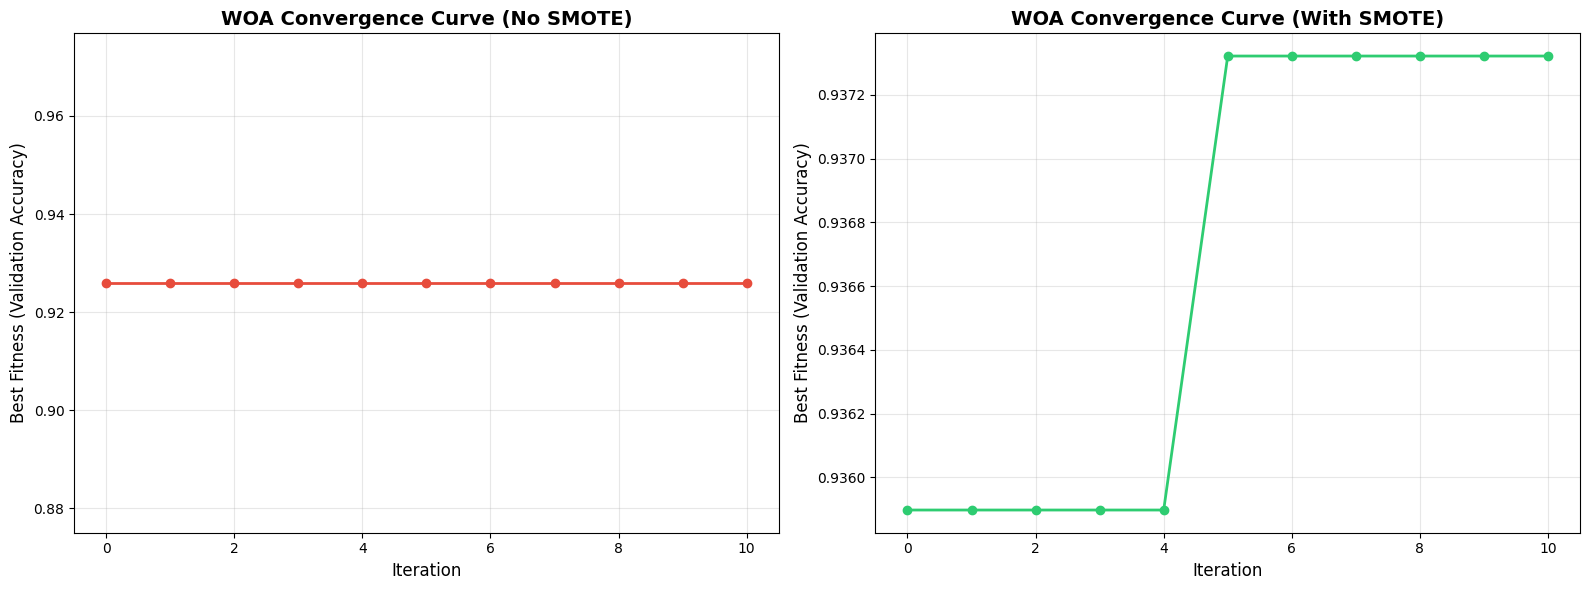

In [ ]:
# ============================================================================
# PLOT WOA CONVERGENCE CURVES
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: WOA Convergence (No SMOTE)
axes[0].plot(range(len(fitness_hist_no_smote)), fitness_hist_no_smote,
             marker='o', linewidth=2, markersize=6, color='#e74c3c')
axes[0].set_title('WOA Convergence Curve (No SMOTE)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Best Fitness (Validation Accuracy)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot 2: WOA Convergence (With SMOTE)
axes[1].plot(range(len(fitness_hist_with_smote)), fitness_hist_with_smote,
             marker='o', linewidth=2, markersize=6, color='#2ecc71')
axes[1].set_title('WOA Convergence Curve (With SMOTE)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Best Fitness (Validation Accuracy)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

EVALUATE ALL MODELS

In [ ]:
# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================

# Predictions
y_pred_cnn_no_smote = np.argmax(model_cnn_no_smote.predict(X_test, verbose=0), axis=1)
y_pred_cnn_with_smote = np.argmax(model_cnn_with_smote.predict(X_test, verbose=0), axis=1)
y_pred_cnn_woa_no_smote = np.argmax(model_cnn_woa_no_smote.predict(X_test, verbose=0), axis=1)
y_pred_cnn_woa_with_smote = np.argmax(model_cnn_woa_with_smote.predict(X_test, verbose=0), axis=1)

# Calculate metrics for all models
models_results = {}

for model_name, y_pred in [
    ("CNN (No SMOTE)", y_pred_cnn_no_smote),
    ("CNN (With SMOTE)", y_pred_cnn_with_smote),
    ("CNN+WOA (No SMOTE)", y_pred_cnn_woa_no_smote),
    ("CNN+WOA (With SMOTE)", y_pred_cnn_woa_with_smote)
]:
    models_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average="macro", zero_division=0),
        'recall': recall_score(y_test, y_pred, average="macro", zero_division=0),
        'f1': f1_score(y_test, y_pred, average="macro", zero_division=0),
        'predictions': y_pred
    }

# Display results
print("\n" + "="*70)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*70)

comparison_df = pd.DataFrame(models_results).T
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Predictions']
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

print(comparison_df.to_string())

# Highlight best performers
print("\n" + "-"*70)
print("BEST PERFORMERS:")
print("-"*70)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:<12}: {best_model:<25} ({best_value:.4f})")


MODEL COMPARISON - TEST SET PERFORMANCE
                      Accuracy Precision    Recall  F1-Score
CNN (No SMOTE)        0.890235  0.731083  0.775164  0.729153
CNN (With SMOTE)      0.933713  0.830797  0.824396  0.827301
CNN+WOA (No SMOTE)    0.923022  0.808496   0.79583  0.800631
CNN+WOA (With SMOTE)  0.929437  0.813389  0.789318  0.799248

----------------------------------------------------------------------
BEST PERFORMERS:
----------------------------------------------------------------------
Accuracy    : CNN (With SMOTE)          (0.9337)
Precision   : CNN (With SMOTE)          (0.8308)
Recall      : CNN (With SMOTE)          (0.8244)
F1-Score    : CNN (With SMOTE)          (0.8273)


DETAILED CLASSIFICATION REPORTS

In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for model_name, results in models_results.items():
    print(f"\n{model_name}:")
    print("-" * 70)
    print(classification_report(y_test, results['predictions'], target_names=class_names))


DETAILED CLASSIFICATION REPORTS

CNN (No SMOTE):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.99      0.98      0.99       975
  monoclinic       0.68      0.84      0.75       174
orthorhombic       0.86      0.55      0.67       201
  tetragonal       0.39      0.74      0.51        53

    accuracy                           0.89      1403
   macro avg       0.73      0.78      0.73      1403
weighted avg       0.91      0.89      0.89      1403


CNN (With SMOTE):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.99      0.99      0.99       975
  monoclinic       0.82      0.83      0.82       174
orthorhombic       0.82      0.84      0.83       201
  tetragonal       0.69      0.64      0.67        53

    accuracy                           0.93      1403
   macro avg       0.83     

CONFUSION MATRICES

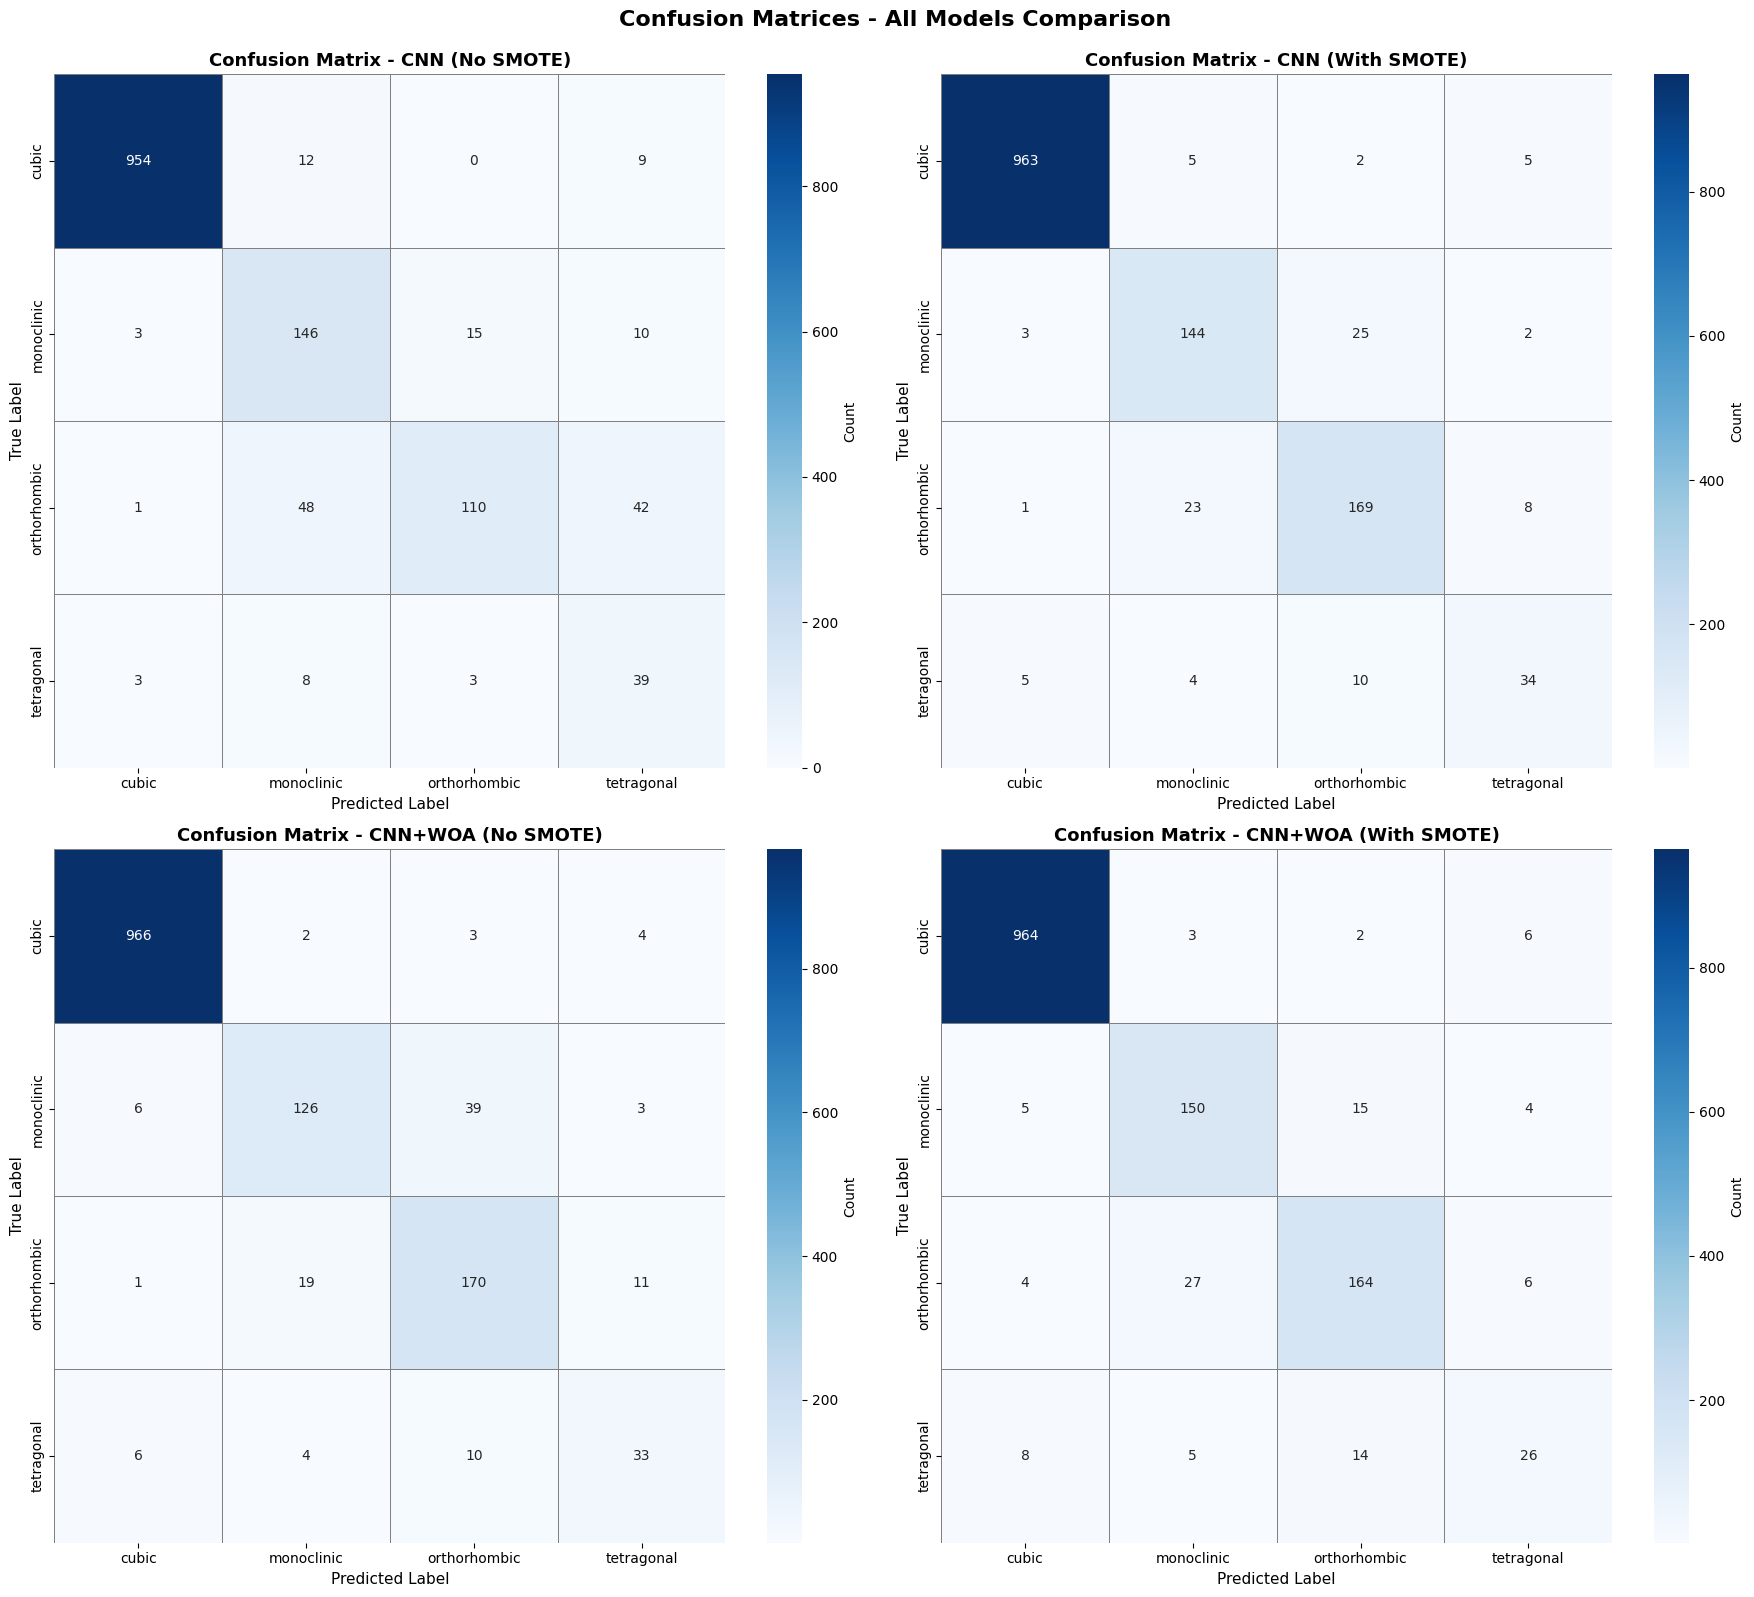

In [ ]:
# ============================================================================
# CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(models_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray',
                ax=axes[idx])

    axes[idx].set_title(f'Confusion Matrix - {model_name}', fontweight='bold', fontsize=13)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices - All Models Comparison', fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

PER-CLASS ACCURACY COMPARISON


PER-CLASS ACCURACY COMPARISON
              CNN (No SMOTE)  CNN (With SMOTE)  CNN+WOA (No SMOTE)  CNN+WOA (With SMOTE)
cubic               0.978462          0.987692            0.990769              0.988718
monoclinic          0.839080          0.827586            0.724138              0.862069
orthorhombic        0.547264          0.840796            0.845771              0.815920
tetragonal          0.735849          0.641509            0.622642              0.490566


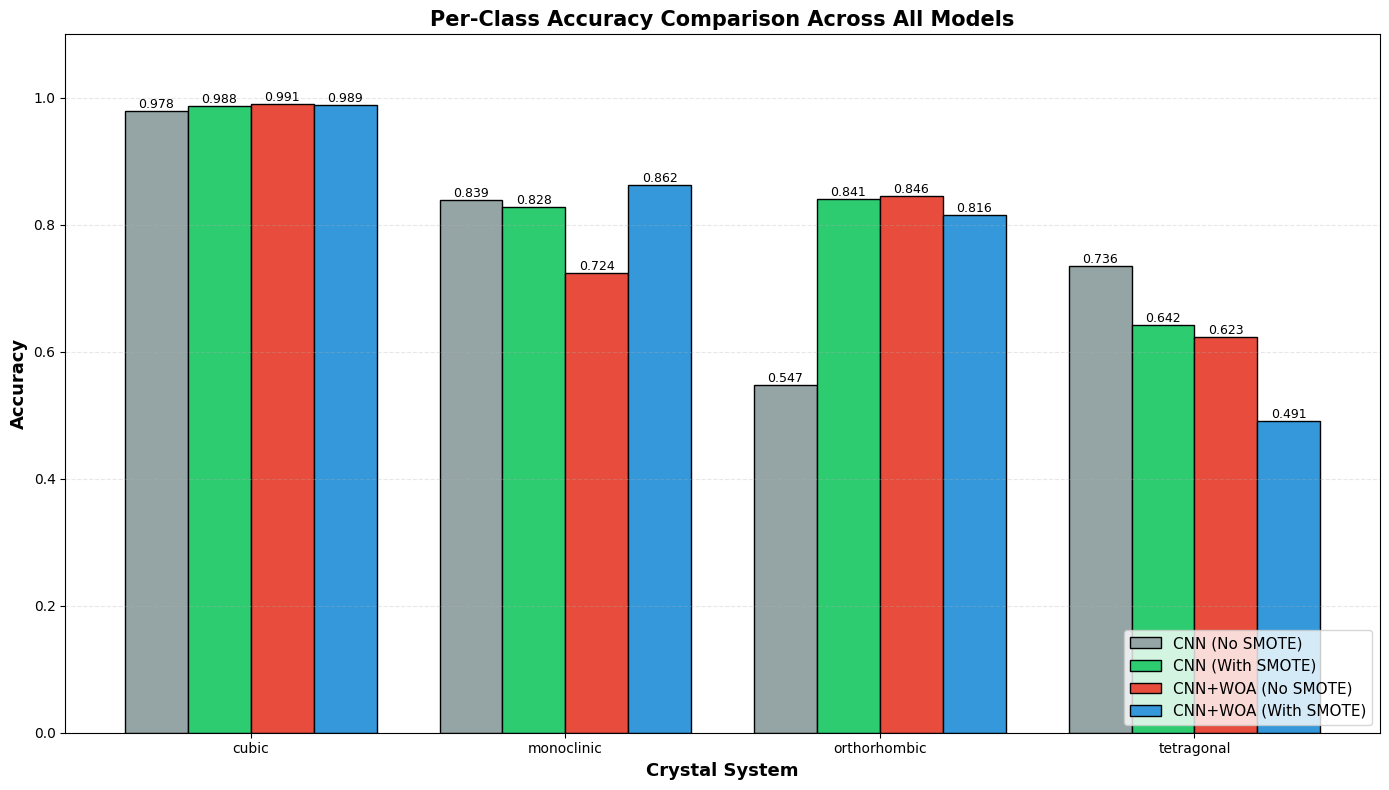

In [ ]:
# ============================================================================
# PER-CLASS ACCURACY COMPARISON
# ============================================================================

print("\n" + "="*70)
print("PER-CLASS ACCURACY COMPARISON")
print("="*70)

per_class_results = {}

for model_name, results in models_results.items():
    cm = confusion_matrix(y_test, results['predictions'])
    per_class_acc = []

    for i in range(len(class_names)):
        if cm[i].sum() > 0:
            per_class_acc.append(cm[i, i] / cm[i].sum())
        else:
            per_class_acc.append(0.0)

    per_class_results[model_name] = per_class_acc

# Create DataFrame
per_class_df = pd.DataFrame(per_class_results, index=class_names)
print(per_class_df.to_string())

# Visualize per-class accuracy
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(class_names))
width = 0.2

colors = ['#95a5a6', '#2ecc71', '#e74c3c', '#3498db']

for idx, (model_name, color) in enumerate(zip(per_class_results.keys(), colors)):
    offset = width * (idx - 1.5)
    bars = ax.bar(x + offset, per_class_results[model_name], width,
                  label=model_name, color=color, edgecolor='black', linewidth=1)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Crystal System', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Per-Class Accuracy Comparison Across All Models', fontweight='bold', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

FEATURE EXTRACTION AND t-SNE VISUALIZATION

In [ ]:
# ============================================================================
# FEATURE EXTRACTION AND t-SNE VISUALIZATION
# ============================================================================

def extract_cnn_features(model, X_data):
    """Extract features from feature layer"""
    if len(X_data.shape) == 2:
        X_data = X_data[..., np.newaxis]
    feature_layer = model.get_layer("feature_layer")
    feat_model = Model(inputs=model.input, outputs=feature_layer.output)
    return feat_model.predict(X_data, verbose=0, batch_size=32)

print("\n" + "="*70)
print("EXTRACTING FEATURES FOR t-SNE VISUALIZATION")
print("="*70)

# Extract features from all models
features_cnn_no_smote = extract_cnn_features(model_cnn_no_smote, X_test_raw)
features_cnn_with_smote = extract_cnn_features(model_cnn_with_smote, X_test_raw)
features_cnn_woa_no_smote = extract_cnn_features(model_cnn_woa_no_smote, X_test_raw)
features_cnn_woa_with_smote = extract_cnn_features(model_cnn_woa_with_smote, X_test_raw)

print("✓ Feature extraction complete for all models!")


EXTRACTING FEATURES FOR t-SNE VISUALIZATION
✓ Feature extraction complete for all models!


t-SNE VISUALIZATION FOR ALL MODELS

In [ ]:
# ============================================================================
# t-SNE VISUALIZATION FOR ALL MODELS
# ============================================================================

print("\n" + "="*70)
print("GENERATING t-SNE VISUALIZATIONS")
print("="*70)

# Apply t-SNE to all feature sets
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000, verbose=0)

print("Applying t-SNE to CNN (No SMOTE) features...")
X_tsne_cnn_no_smote = tsne.fit_transform(features_cnn_no_smote)

print("Applying t-SNE to CNN (With SMOTE) features...")
X_tsne_cnn_with_smote = tsne.fit_transform(features_cnn_with_smote)

print("Applying t-SNE to CNN+WOA (No SMOTE) features...")
X_tsne_cnn_woa_no_smote = tsne.fit_transform(features_cnn_woa_no_smote)

print("Applying t-SNE to CNN+WOA (With SMOTE) features...")
X_tsne_cnn_woa_with_smote = tsne.fit_transform(features_cnn_woa_with_smote)

print("✓ t-SNE transformation complete for all models!")


GENERATING t-SNE VISUALIZATIONS
Applying t-SNE to CNN (No SMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying t-SNE to CNN (With SMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying t-SNE to CNN+WOA (No SMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying t-SNE to CNN+WOA (With SMOTE) features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ t-SNE transformation complete for all models!


PLOT t-SNE VISUALIZATIONS

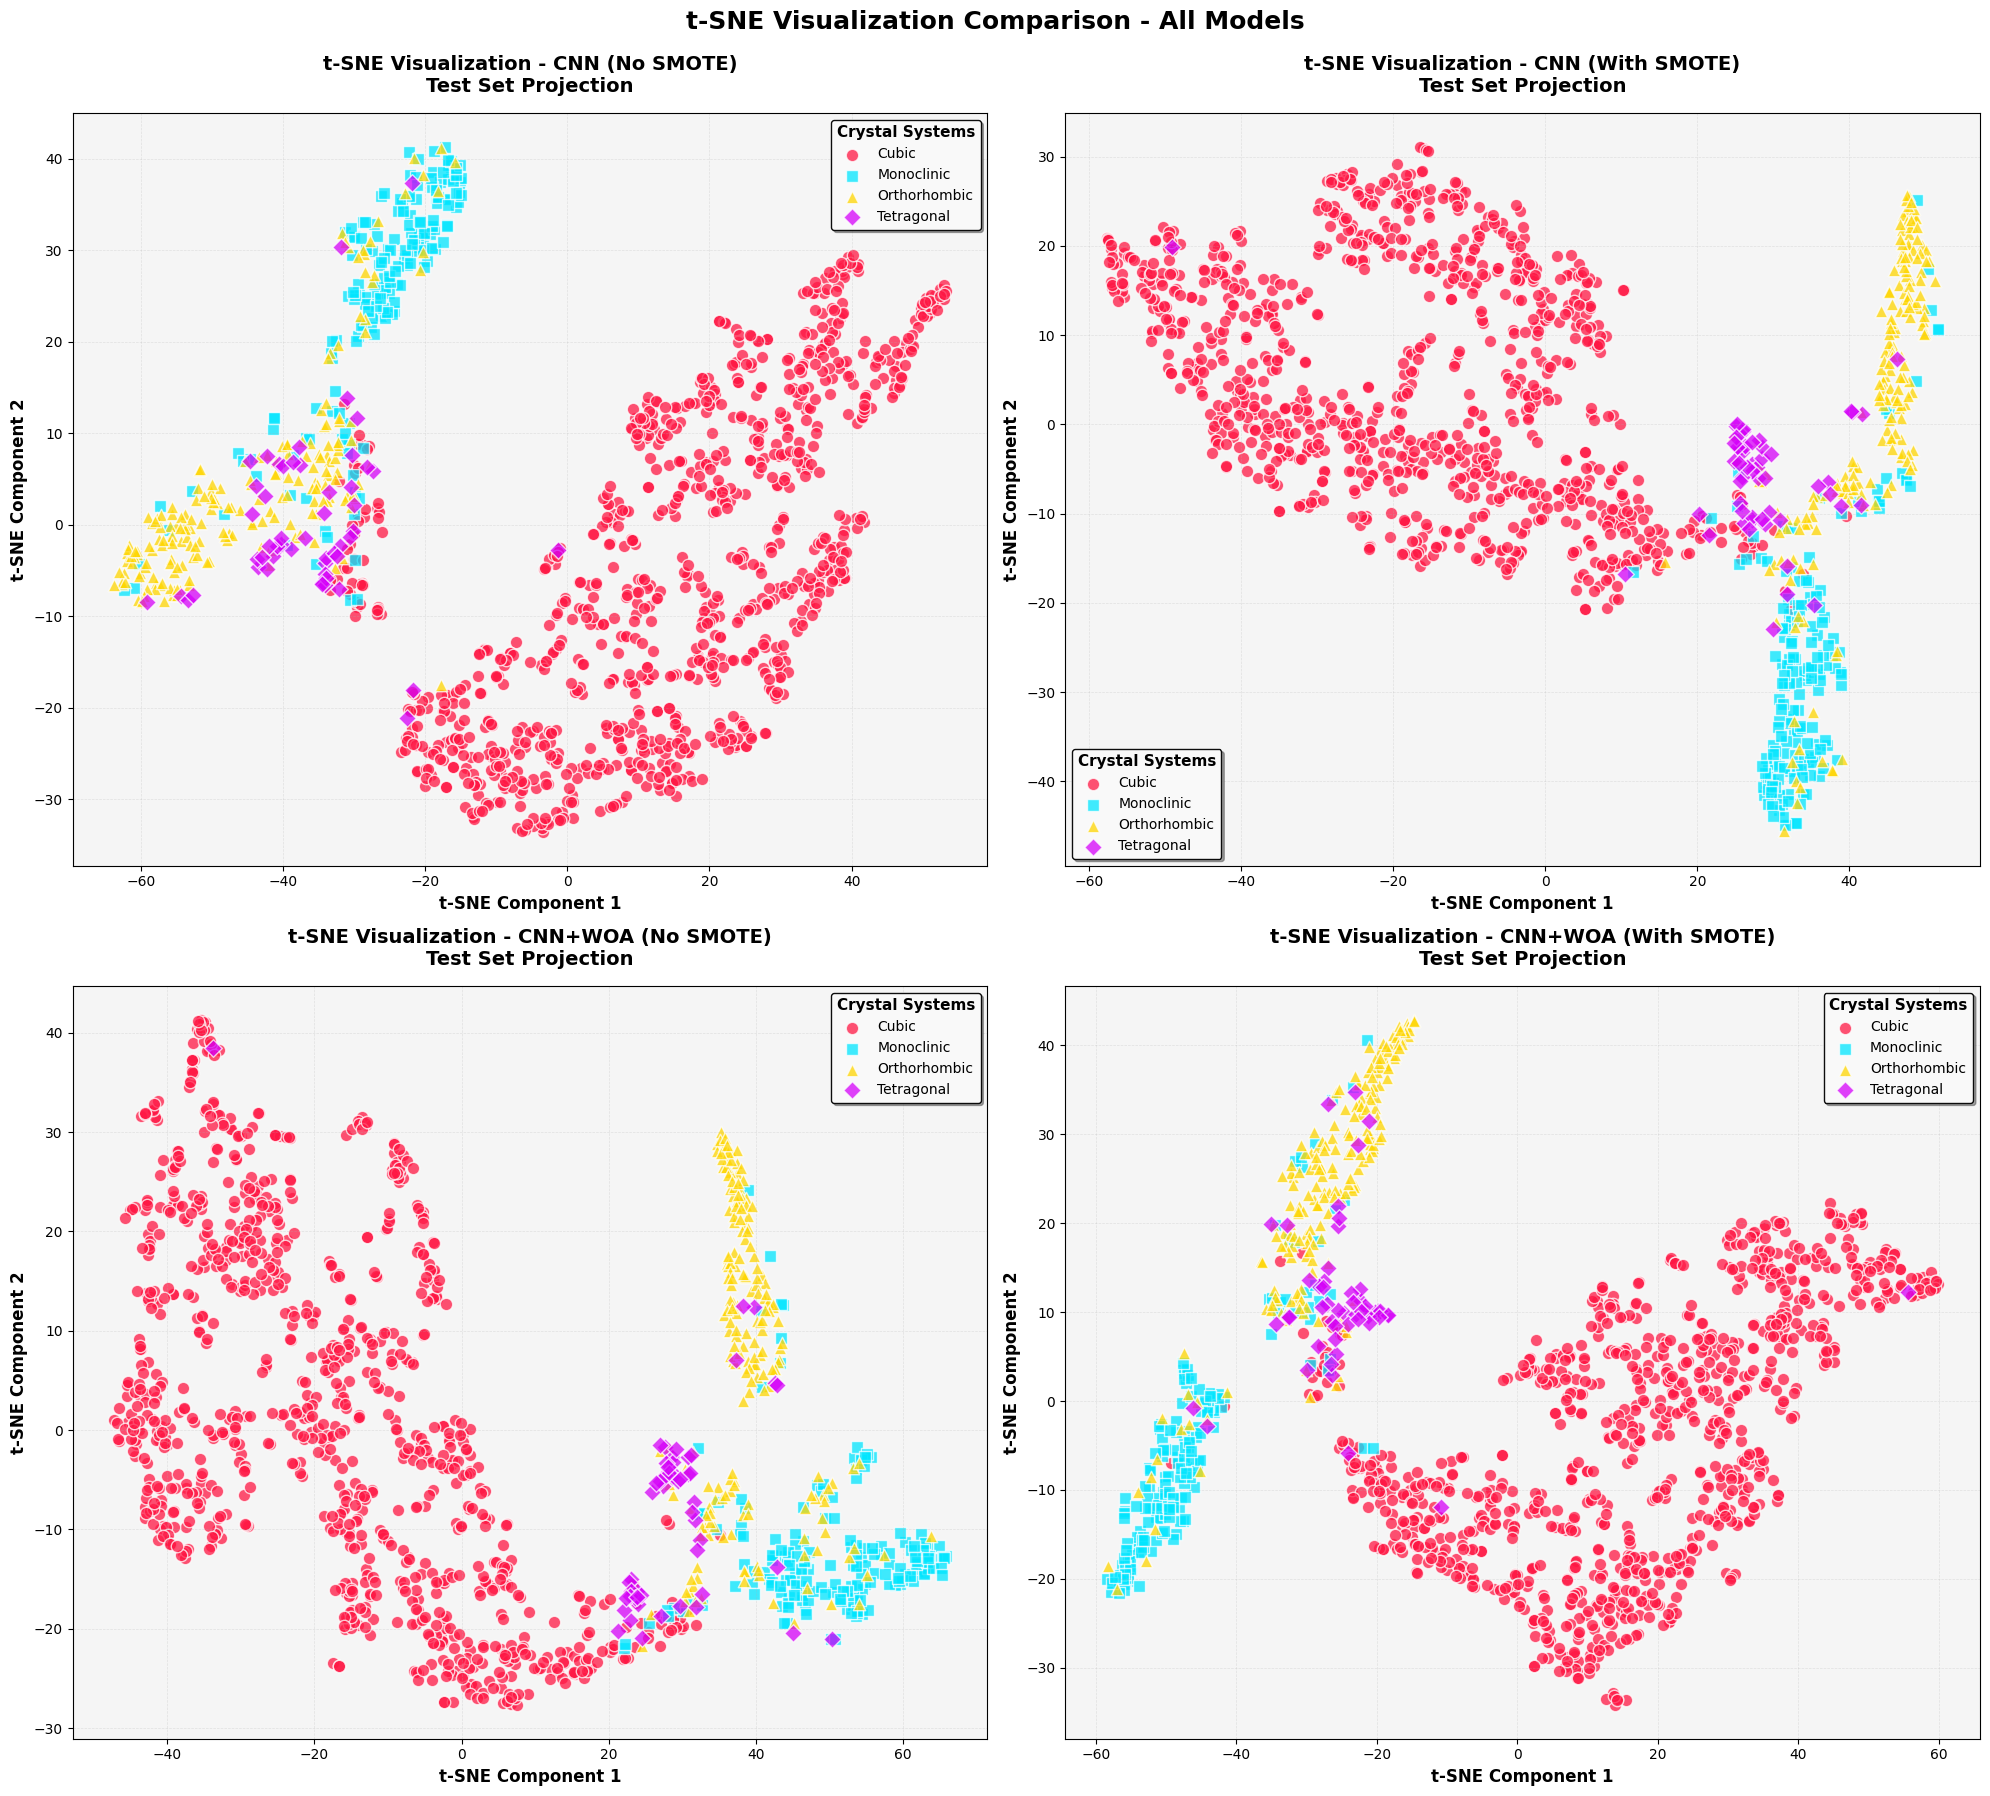


✓ t-SNE visualizations complete!
✓ Visualized 1403 test samples for each model


In [ ]:
# ============================================================================
# PLOT t-SNE VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.ravel()

# Bright and distinct color palette
colors_bright = [
    '#FF1744',  # Bright Red - Cubic
    '#00E5FF',  # Bright Cyan - Monoclinic
    '#FFD600',  # Bright Yellow - Orthorhombic
    '#D500F9'   # Bright Purple - Tetragonal
]

markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

tsne_data = [
    (X_tsne_cnn_no_smote, "CNN (No SMOTE)"),
    (X_tsne_cnn_with_smote, "CNN (With SMOTE)"),
    (X_tsne_cnn_woa_no_smote, "CNN+WOA (No SMOTE)"),
    (X_tsne_cnn_woa_with_smote, "CNN+WOA (With SMOTE)")
]

for idx, (X_tsne, title) in enumerate(tsne_data):
    ax = axes[idx]

    for i, name in enumerate(class_names):
        mask = (y_test == i)
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=colors_bright[i],
                   label=name.capitalize(),
                   s=80,
                   alpha=0.75,
                   edgecolors='white',
                   linewidths=1.0,
                   marker=markers[i])

    ax.set_title(f't-SNE Visualization - {title}\nTest Set Projection',
                 fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')

    legend = ax.legend(fontsize=10, loc='best', framealpha=0.95,
                       edgecolor='black', fancybox=True, shadow=True)
    legend.set_title('Crystal Systems', prop={'size': 11, 'weight': 'bold'})

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_facecolor('#F5F5F5')

plt.suptitle('t-SNE Visualization Comparison - All Models',
            fontweight='bold', fontsize=18, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ t-SNE visualizations complete!")
print(f"✓ Visualized {len(X_test)} test samples for each model")

TRAINING HISTORY COMPARISON

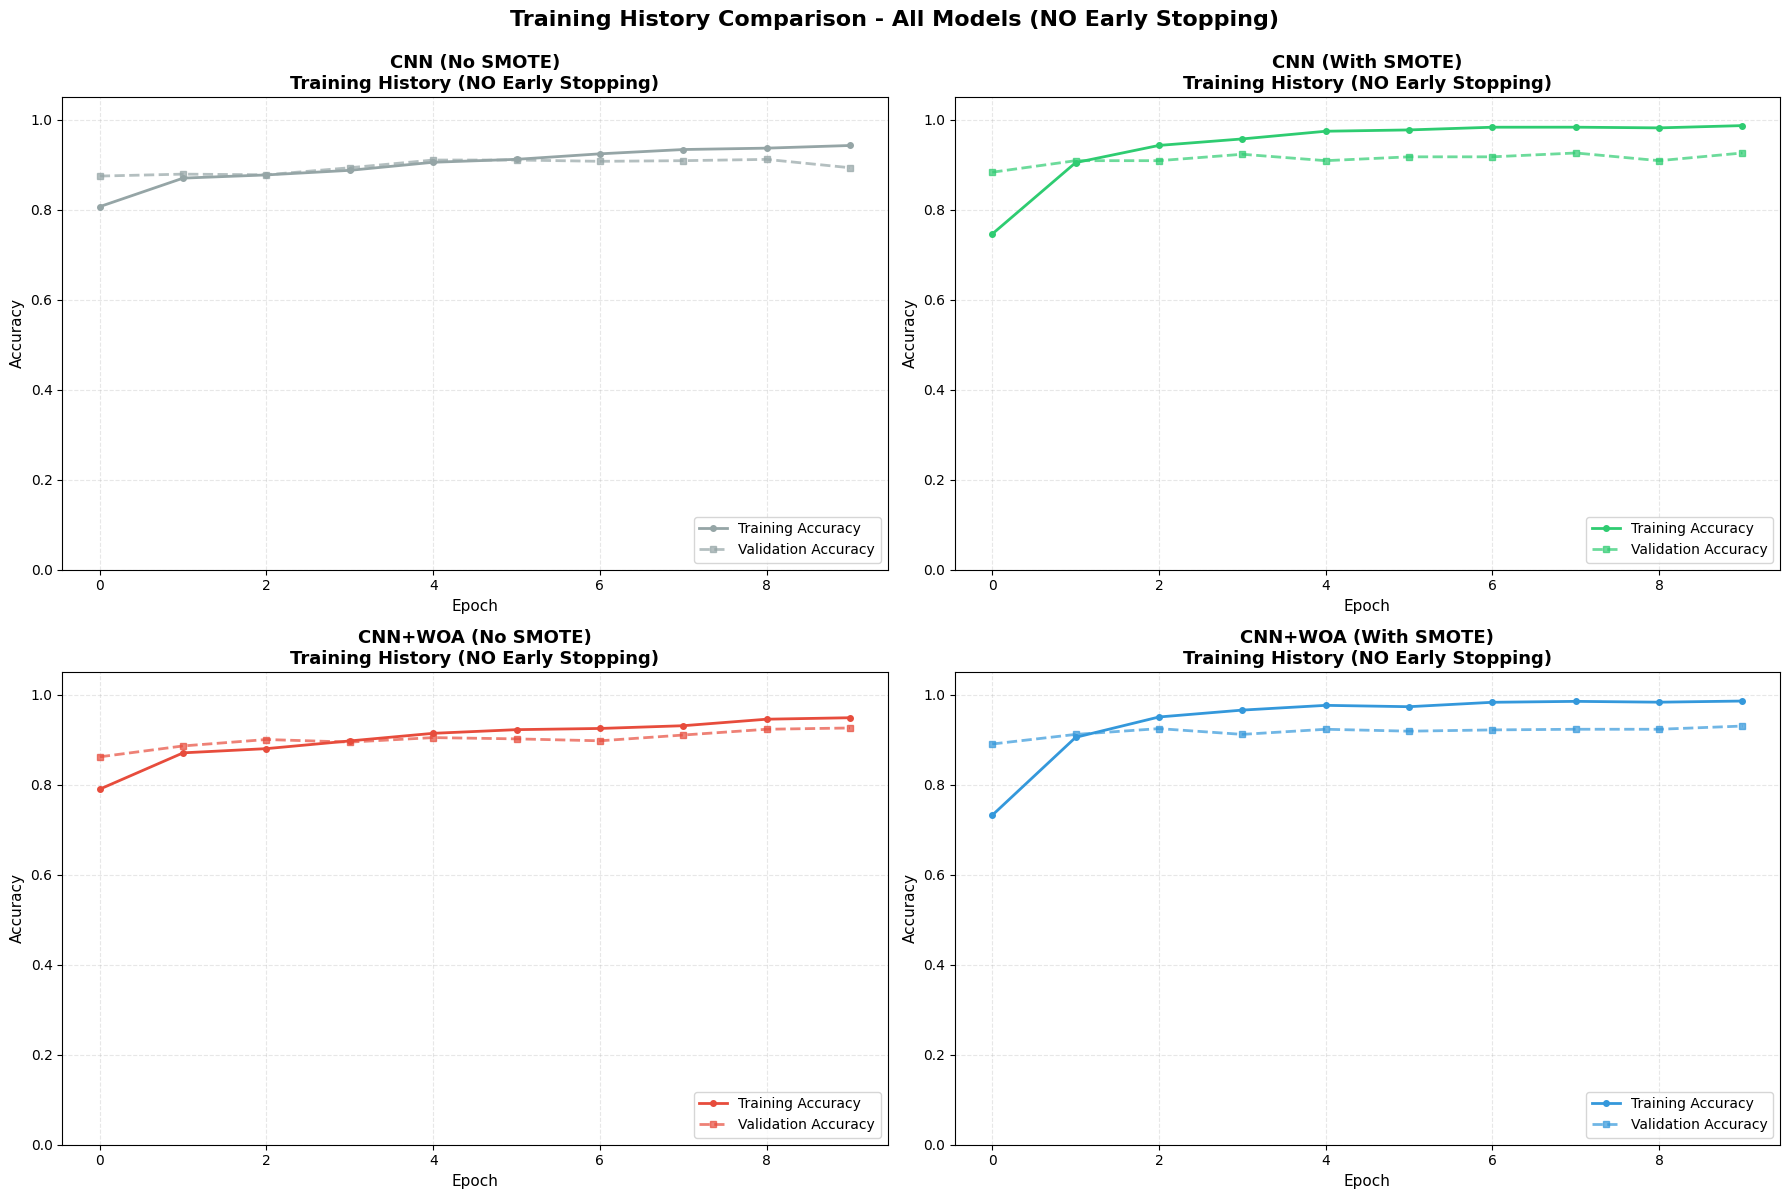

In [ ]:
# ============================================================================
# TRAINING HISTORY COMPARISON
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

histories = [
    (history_cnn_no_smote, "CNN (No SMOTE)", '#95a5a6'),
    (history_cnn_with_smote, "CNN (With SMOTE)", '#2ecc71'),
    (history_cnn_woa_no_smote, "CNN+WOA (No SMOTE)", '#e74c3c'),
    (history_cnn_woa_with_smote, "CNN+WOA (With SMOTE)", '#3498db')
]

for idx, (history, title, color) in enumerate(histories):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]

    # Plot training and validation accuracy
    ax.plot(history.history['accuracy'], label='Training Accuracy',
            linewidth=2, color=color, linestyle='-', marker='o', markersize=4)
    ax.plot(history.history['val_accuracy'], label='Validation Accuracy',
            linewidth=2, color=color, linestyle='--', marker='s', markersize=4, alpha=0.7)

    ax.set_title(f'{title}\nTraining History (NO Early Stopping)', fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.05)

plt.suptitle('Training History Comparison - All Models (NO Early Stopping)',
            fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

FINAL SUMMARY AND RECOMMENDATIONS

In [ ]:
# ============================================================================
# FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================

print("\n" + "="*70)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("="*70)

# Find overall best model
best_model_name = comparison_df['Accuracy'].idxmax()
best_accuracy = comparison_df['Accuracy'].max()

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.4f}")
print(f"   Test F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")

print("\n" + "-"*70)
print("KEY FINDINGS:")
print("-"*70)

# Compare SMOTE effect
cnn_improvement = (models_results['CNN (With SMOTE)']['accuracy'] -
                  models_results['CNN (No SMOTE)']['accuracy'])
woa_improvement = (models_results['CNN+WOA (With SMOTE)']['accuracy'] -
                  models_results['CNN+WOA (No SMOTE)']['accuracy'])

print(f"1. SMOTE Impact on CNN:")
print(f"   Accuracy change: {cnn_improvement:+.4f} ({cnn_improvement*100:+.2f}%)")

print(f"\n2. SMOTE Impact on CNN+WOA:")
print(f"   Accuracy change: {woa_improvement:+.4f} ({woa_improvement*100:+.2f}%)")

# Compare WOA effect
woa_effect_no_smote = (models_results['CNN+WOA (No SMOTE)']['accuracy'] -
                       models_results['CNN (No SMOTE)']['accuracy'])
woa_effect_with_smote = (models_results['CNN+WOA (With SMOTE)']['accuracy'] -
                         models_results['CNN (With SMOTE)']['accuracy'])

print(f"\n3. WOA Optimization Impact (No SMOTE):")
print(f"   Accuracy change: {woa_effect_no_smote:+.4f} ({woa_effect_no_smote*100:+.2f}%)")

print(f"\n4. WOA Optimization Impact (With SMOTE):")
print(f"   Accuracy change: {woa_effect_with_smote:+.4f} ({woa_effect_with_smote*100:+.2f}%)")

print("\n" + "="*70)
print("TRAINING CONFIGURATION:")
print("="*70)
print(f"✓ Epochs: {EPOCHS_FINAL}")
print(f"✓ Early Stopping: DISABLED")
print(f"✓ Data Split: 70% Train / 10% Validation / 20% Test")
print(f"✓ SMOTE Applied: Training data only")

print("\n" + "="*70)
print("✓ EXPERIMENT COMPLETE!")
print("="*70)


FINAL SUMMARY AND RECOMMENDATIONS

🏆 BEST MODEL: CNN (With SMOTE)
   Test Accuracy: 0.9337
   Test F1-Score: 0.8273

----------------------------------------------------------------------
KEY FINDINGS:
----------------------------------------------------------------------
1. SMOTE Impact on CNN:
   Accuracy change: +0.0435 (+4.35%)

2. SMOTE Impact on CNN+WOA:
   Accuracy change: +0.0064 (+0.64%)

3. WOA Optimization Impact (No SMOTE):
   Accuracy change: +0.0328 (+3.28%)

4. WOA Optimization Impact (With SMOTE):
   Accuracy change: -0.0043 (-0.43%)

TRAINING CONFIGURATION:
✓ Epochs: 10
✓ Early Stopping: DISABLED
✓ Data Split: 70% Train / 10% Validation / 20% Test
✓ SMOTE Applied: Training data only

✓ EXPERIMENT COMPLETE!
